In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os

print(os.listdir("/kaggle/input"))

[]


In [ ]:
import kagglehub
path = kagglehub.dataset_download("jangedoo/utkface-new")
print(os.listdir(path)[:10])

100%|██████████| 331M/331M [00:14<00:00, 23.5MB/s]

Extracting files...


['utkface_aligned_cropped', 'UTKFace', 'crop_part1']


In [ ]:
path = path + "/UTKFace"

In [ ]:
import collections

print("Training Distribution:")
print(collections.Counter(g_train))

Training Distribution:


NameError: name 'g_train' is not defined

In [ ]:
import os
import numpy as np
import cv2
import collections
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---- LOAD DATASET ----
import kagglehub
path = kagglehub.dataset_download("jangedoo/utkface-new")

# Correct folder
base_path = path + "/UTKFace"

X, y, g = [], [], []
max_samples = 4000
# ---- LOAD IMAGES (NO BIAS ADDED) ----
for file in os.listdir(base_path):
    try:
        race = int(file.split("_")[2])

        img = cv2.imread(os.path.join(base_path, file))
        if img is None:
            continue

        # ✅ Convert to grayscale (better for LogisticRegression)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (32, 32))

        X.append(img.flatten())
        y.append(race % 2)   # simple label
        g.append(race)       # group (race)

    except:
        continue

X = np.array(X)
y = np.array(y)
g = np.array(g)

# ---- SPLIT ----
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, g, test_size=0.3, random_state=42
)

# ---- SHOW REAL DATA IMBALANCE ----
print("Training Distribution:")
print(collections.Counter(g_train))

# ---- BASELINE MODEL ----
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

# ---- WEIGHTED MODEL ----
weights = np.ones(len(y_train))

# Increase importance of Black group (race = 1)
weights[g_train == 1] = 6

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train, y_train, sample_weight=weights)
pred2 = model2.predict(X_test)

# ---- RESULTS FUNCTION ----
def acc_by_group(pred):
    for group in np.unique(g_test):
        acc = accuracy_score(y_test[g_test == group], pred[g_test == group])
        print(f"Group {group} Accuracy: {acc:.2f}")

# ---- PRINT RESULTS ----
print("\nBaseline Model:")
acc_by_group(pred1)

print("\nWeighted Model:")
acc_by_group(pred2)

# ---- SHOW WEIGHTS (PROOF) ----
print("\nWeight Summary:")
print("Unique weights used:", np.unique(weights))
print("Number of boosted samples (Black group):", np.sum(weights == 6))

Using Colab cache for faster access to the 'utkface-new' dataset.
Training Distribution:
Counter({np.int64(0): 7088, np.int64(1): 3155, np.int64(3): 2782, np.int64(2): 2392, np.int64(4): 1176})


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Baseline Model:
Group 0 Accuracy: 0.90
Group 1 Accuracy: 0.79
Group 2 Accuracy: 0.91
Group 3 Accuracy: 0.65
Group 4 Accuracy: 0.70

Weighted Model:
Group 0 Accuracy: 0.81
Group 1 Accuracy: 0.90
Group 2 Accuracy: 0.82
Group 3 Accuracy: 0.70
Group 4 Accuracy: 0.58

Weight Summary:
Unique weights used: [1. 6.]
Number of boosted samples (Black group): 3155


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import confusion_matrix

def fp_fn_by_group(y_true, pred, groups):
    for g in np.unique(groups):
        idx = groups == g

        tn, fp, fn, tp = confusion_matrix(y_true[idx], pred[idx]).ravel()

        print(f"\nGroup {g}")
        print(f"TP: {tp}")
        print(f"TN: {tn}")
        print(f"FP: {fp}")
        print(f"FN: {fn}")
        print("\nBaseline FP/FN Analysis:")
fp_fn_by_group(y_test, pred1, g_test)

print("\nWeighted FP/FN Analysis:")
fp_fn_by_group(y_test, pred2, g_test)


Group 0
TP: 0
TN: 2683
FP: 307
FN: 0

Baseline FP/FN Analysis:

Group 1
TP: 1085
TN: 0
FP: 0
FN: 286

Baseline FP/FN Analysis:

Group 2
TP: 0
TN: 947
FP: 95
FN: 0

Baseline FP/FN Analysis:

Group 3
TP: 781
TN: 0
FP: 0
FN: 412

Baseline FP/FN Analysis:

Group 4
TP: 0
TN: 361
FP: 155
FN: 0

Baseline FP/FN Analysis:

Weighted FP/FN Analysis:

Group 0
TP: 0
TN: 2428
FP: 562
FN: 0

Baseline FP/FN Analysis:

Group 1
TP: 1232
TN: 0
FP: 0
FN: 139

Baseline FP/FN Analysis:

Group 2
TP: 0
TN: 859
FP: 183
FN: 0

Baseline FP/FN Analysis:

Group 3
TP: 830
TN: 0
FP: 0
FN: 363

Baseline FP/FN Analysis:

Group 4
TP: 0
TN: 297
FP: 219
FN: 0

Baseline FP/FN Analysis:


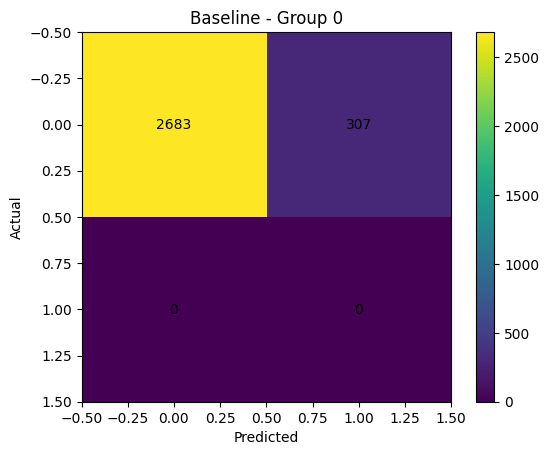

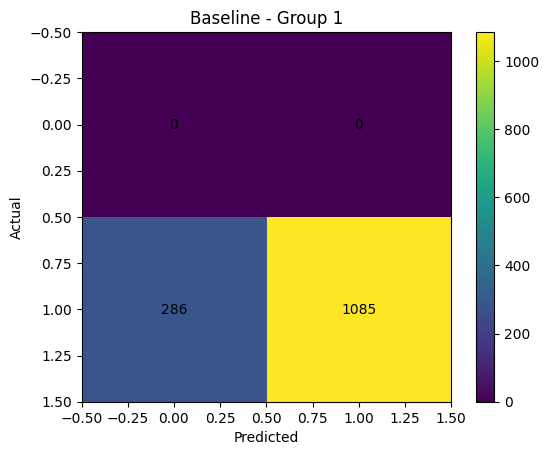

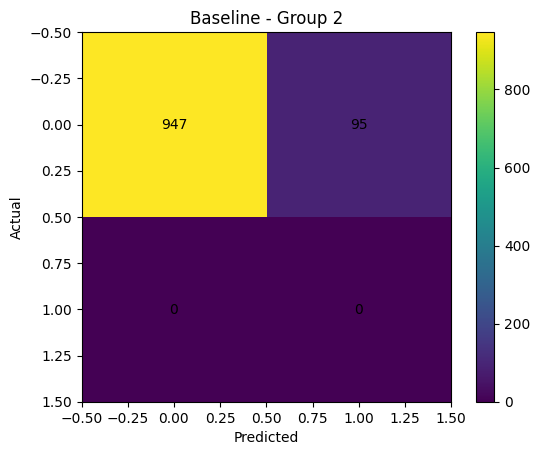

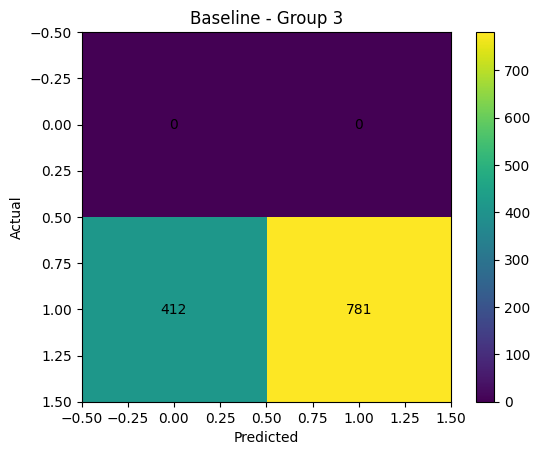

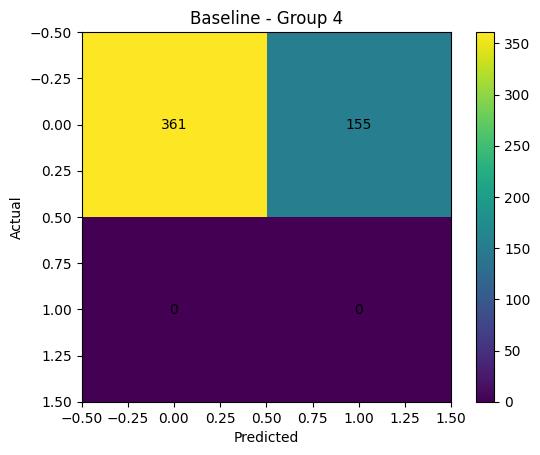

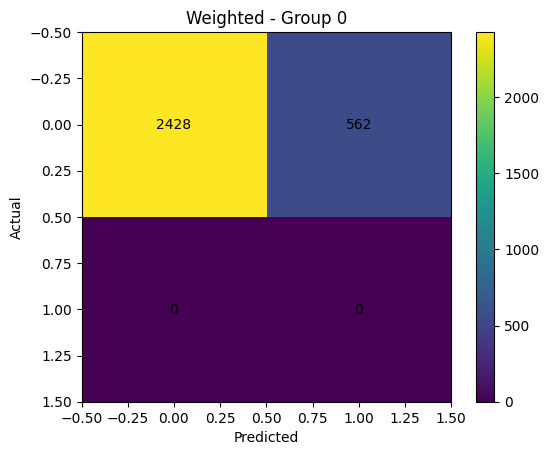

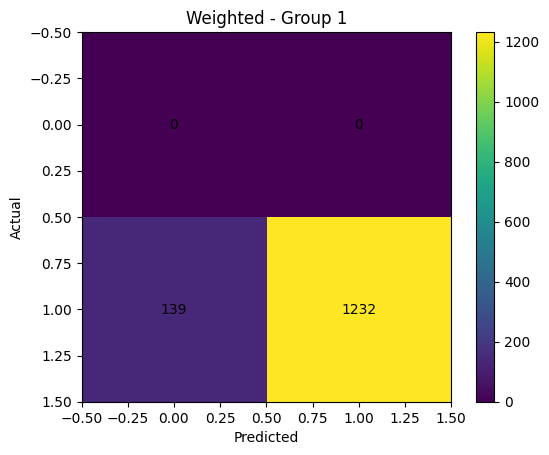

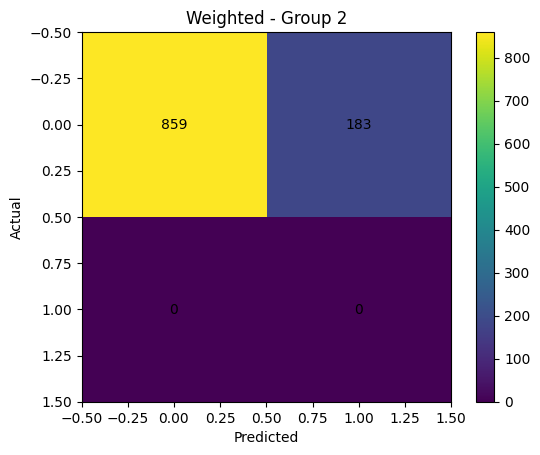

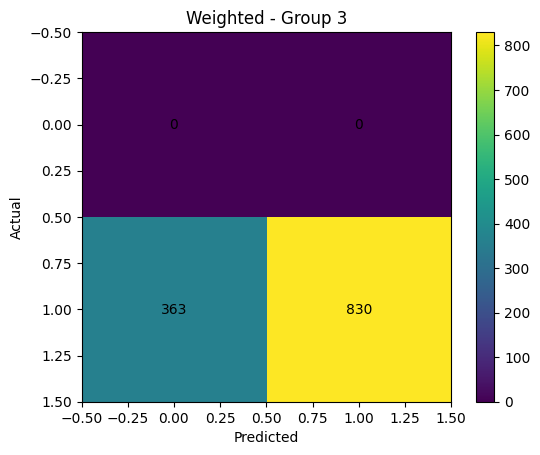

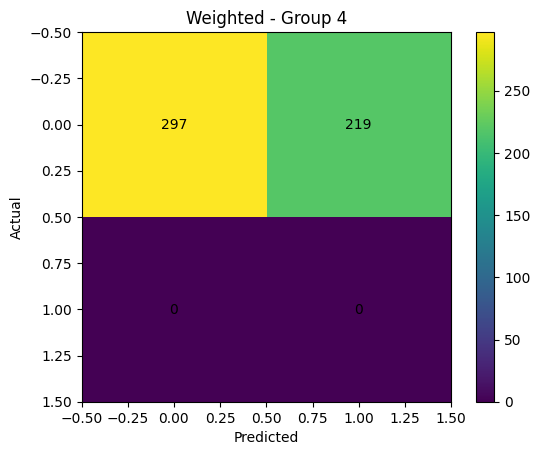

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_by_group(y_true, pred, groups, title_prefix):
    for g in np.unique(groups):
        idx = groups == g
        cm = confusion_matrix(y_true[idx], pred[idx])

        plt.figure()
        plt.imshow(cm)
        plt.title(f"{title_prefix} - Group {g}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        # Add numbers inside boxes
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha='center', va='center')

        plt.colorbar()
        plt.show()

# Baseline heatmaps
plot_confusion_by_group(y_test, pred1, g_test, "Baseline")

# Weighted heatmaps
plot_confusion_by_group(y_test, pred2, g_test, "Weighted")

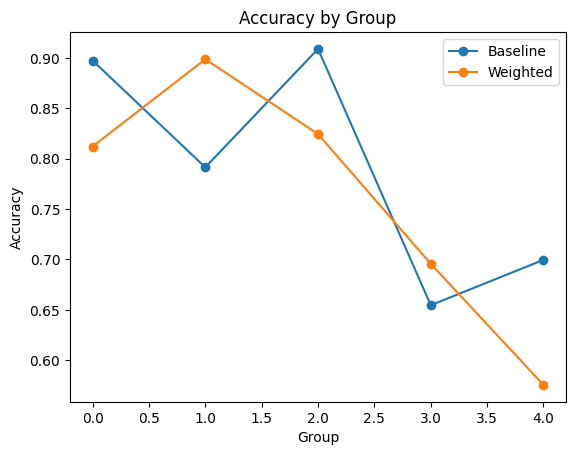

In [ ]:
def get_group_accuracy(pred):
    accs = []
    groups = sorted(np.unique(g_test))

    for g in groups:
        acc = accuracy_score(y_test[g_test == g], pred[g_test == g])
        accs.append(acc)

    return groups, accs

groups, base_acc = get_group_accuracy(pred1)
_, weighted_acc = get_group_accuracy(pred2)

plt.figure()
plt.plot(groups, base_acc, marker='o', label='Baseline')
plt.plot(groups, weighted_acc, marker='o', label='Weighted')

plt.xlabel("Group")
plt.ylabel("Accuracy")
plt.title("Accuracy by Group")
plt.legend()
plt.show()

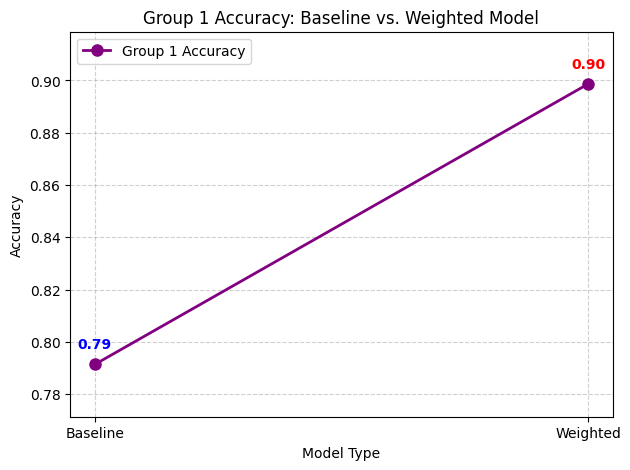

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `base_acc` and `weighted_acc` are available from cell 9faTkOH7_mza

# Extract accuracies for Group 1 (index 1)
group1_baseline_accuracy = base_acc[1]
group1_weighted_accuracy = weighted_acc[1]

models = ['Baseline', 'Weighted']
accuracies = [group1_baseline_accuracy, group1_weighted_accuracy]

plt.figure(figsize=(7, 5))

# Plot Baseline point as a distinct visual element
plt.scatter(models[0], accuracies[0], color='blue', s=150, zorder=5, label=f'Baseline: {accuracies[0]:.2f}', edgecolor='black')

# Plot Weighted point as a distinct visual element
plt.scatter(models[1], accuracies[1], color='red', s=150, zorder=5, label=f'Weighted: {accuracies[1]:.2f}', edgecolor='black')

# Add a subtle connecting line to show the improvement/trend
plt.plot(models, accuracies, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

# Add text labels explicitly for the specific accuracy values, positioned below the points
plt.text(models[0], accuracies[0] - 0.008, f'{accuracies[0]:.2f}', color='blue', ha='center', va='top', fontsize=10, fontweight='bold')
plt.text(models[1], accuracies[1] - 0.008, f'{accuracies[1]:.2f}', color='red', ha='center', va='top', fontsize=10, fontweight='bold')

# Labels and title
plt.title("Group 1 Accuracy: Baseline vs. Weighted Model")
plt.xlabel("Model Type")
plt.ylabel("Accuracy")

# Axis range - set based on the specific accuracy values for Group 1
# Use min and max of accuracies for a focused view, with some padding
min_acc = min(accuracies) - 0.02
max_acc = max(accuracies) + 0.02
plt.ylim(min_acc, max_acc)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right') # Adjust legend location to avoid overlap
plt.show()